# On-Device Keyword Spotting — MFCC Training Pipeline

This notebook implements a **full training pipeline** for on-device keyword spotting using Mel-Frequency Cepstral Coefficients (MFCC).  
The MFCC pipeline **exactly mirrors** the CMSIS-DSP implementation running on the Arduino. (The features produced must be comparable)

**Target classes:** `clap`, `tap`, `snap`, `whistle`

**Full pipeline:**
1. Load raw int16 PCM samples from `.txt` files
2. MFCC Feature Extraction
    a. Frame segmentation (256-sample frames, 50 % overlap)
    b. Hamming windowing (spectral leakage reduction)
    c. Real FFT → power spectrum
    d. Mel filter-bank application
    e. Log energy computation
    f. Discrete Cosine Transform (DCT-II) → MFCC coefficients
3. Normalisation & dataset split
4. Train a lightweight **1-D CNN** (Conv → Pool → Conv → Pool → Flatten → Softmax)
10. Evaluate (accuracy + confusion matrix)
11. Export as **TFLite** for Arduino inference


## 1. Install & Import

In [ ]:
!pip install -q librosa numpy matplotlib seaborn scipy scikit-learn tensorflow
print("Packages installed")


Packages installed


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from scipy.fftpack import dct
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import cm

print("TF version :", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TF version : 2.19.0
GPU devices: []


## 2. Global Constants

The configuration here **must match** the values in the Arduino sketch so that Python and
on-device MFCC outputs are identical.


In [ ]:
# ── Audio / dataset ────────────────────────────────────────────────────────────
CLASSES          = ["clap", "tap", "snap", "whistle"]  
NUM_CLASSES      = len(CLASSES)
SAMPLE_RATE      = 16000        # Hz  
SAMPLES_PER_OBS  = 2000         # int16 PCM values per recording
SAMPLES_PER_FILE = 40000        # each .txt file = 20 recordings × 2000 samples
NUM_OBS_PER_CLASS = SAMPLES_PER_FILE // SAMPLES_PER_OBS 

# ── MFCC framing ────────────────────────────────────────────────────────────
FRAME_LEN = 256     # samples per frame  (256 int16 PCM)
HOP_LEN   = 128     # 50 % overlap  → hop = FRAME_LEN / 2
FFT_SIZE  = 256     # RFFT size == FRAME_LEN

# ── Mel filter bank ─────────────────────────────────────────────────────────
N_MELS = 26
F_MIN  = 300.0              # Hz  — low cut (below typical speech fundamental)
F_MAX  = SAMPLE_RATE / 2    # Hz  — Nyquist criterion

# ── MFCC ────────────────────────────────────────────────────────────────────
N_MFCC = 13     # coefficients to keep (0 … 12)

# Derived — frames produced by one 2000-sample recording
N_FRAMES = (SAMPLES_PER_OBS - FRAME_LEN) // HOP_LEN + 1
print(f"Recordings per class : {NUM_OBS_PER_CLASS}")
print(f"Total dataset size   : {NUM_OBS_PER_CLASS * NUM_CLASSES} samples")
print(f"Frames per recording : {N_FRAMES}")
print(f"MFCC shape per sample: ({N_FRAMES}, {N_MFCC})")


Recordings per class : 20
Total dataset size   : 80 samples
Frames per recording : 14
MFCC shape per sample: (14, 13)


## 3. Load Dataset

Each class has **one `.txt` file** containing 40 000 raw int16 PCM values (one per line)
recorded at `SAMPLE_RATE` Hz.  We keep them as-is — no resampling or WAV conversion needed.


In [ ]:
def load_dataset(dataset_dir="/content/dataset/", classes=CLASSES):
    """
    Load raw int16 PCM samples from per-class .txt files.

    Each file contains SAMPLES_PER_FILE (40 000) values = 20 recordings × 2000 samples.
    We split each file into NUM_OBS_PER_CLASS individual observations of SAMPLES_PER_OBS
    samples and assign the class label to each.
    """
    X, y = [], []
    for label_idx, cls in enumerate(classes):
        fpath = os.path.join(dataset_dir, cls + ".txt")
        print(f"Loading {fpath} ...", end=" ")
        if not os.path.exists(fpath):
            print("MISSING — skipping")
            continue
        raw = np.loadtxt(fpath, dtype=np.int16)
        print(f"{len(raw)} values  →  ", end="")

        # Trim to a whole number of observations
        n_obs = len(raw) // SAMPLES_PER_OBS
        raw   = raw[:n_obs * SAMPLES_PER_OBS]

        # Split into (n_obs, SAMPLES_PER_OBS) chunks
        chunks = raw.reshape(n_obs, SAMPLES_PER_OBS)
        print(f"{n_obs} recordings of {SAMPLES_PER_OBS} samples")

        for chunk in chunks:
            X.append(chunk)
            y.append(label_idx)

    return X, np.array(y, dtype=np.int32)


raw_signals, y = load_dataset()
print(f"\nTotal recordings loaded : {len(raw_signals)}")
print("Class distribution:", {CLASSES[i]: int(np.sum(y == i)) for i in range(NUM_CLASSES)})


Loading /content/dataset/clap.txt ... 40000 values  →  20 recordings of 2000 samples
Loading /content/dataset/tap.txt ... 40000 values  →  20 recordings of 2000 samples
Loading /content/dataset/snap.txt ... 40000 values  →  20 recordings of 2000 samples
Loading /content/dataset/whistle.txt ... 40000 values  →  20 recordings of 2000 samples

Total recordings loaded : 80
Class distribution: {'clap': 20, 'tap': 20, 'snap': 20, 'whistle': 20}


## 4. MFCC Pipeline (mirroring Arduino CMSIS-DSP)

The steps below replicate **exactly** the MFCC Pipeline on the Arduino.

### Pipeline steps

1. **Frame segmentation** — 256-sample frames, 50 % overlap  
2. **Hamming window** — spectral leakage 
3. **Real FFT (RFFT)** 
4. **Power spectrum**  
5. **Mel filter bank** — 26 triangular filters spaced on the Mel scale  
6. **Log energy** — to compress dynamic range  
7. **DCT-II** — decorrelates the log-Mel energies → produce MFCC coefficients  


In [ ]:
def hz_to_mel(f):
    """Convert Hz → Mel (O'Shaughnessy formula, same as CMSIS-DSP tables)."""
    return 2595.0 * np.log10(1.0 + f / 700.0)

def mel_to_hz(m):
    return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

def build_mel_filterbank(n_mels=N_MELS, n_fft=FFT_SIZE,
                          sr=SAMPLE_RATE, f_min=F_MIN, f_max=F_MAX):
    mel_min = hz_to_mel(f_min)
    mel_max = hz_to_mel(f_max)
    # n_mels + 2 equally-spaced Mel points (including edge bins)
    mel_points  = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points   = mel_to_hz(mel_points)
    # Map Hz → FFT bin index
    bin_points  = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    n_bins = n_fft // 2 + 1
    fbank  = np.zeros((n_mels, n_bins), dtype=np.float32)

    for m in range(1, n_mels + 1):
        f_left   = bin_points[m - 1]
        f_center = bin_points[m]
        f_right  = bin_points[m + 1]
        for k in range(f_left, f_center):
            if f_center > f_left:
                fbank[m - 1, k] = (k - f_left) / (f_center - f_left)
        for k in range(f_center, f_right):
            if f_right > f_center:
                fbank[m - 1, k] = (f_right - k) / (f_right - f_center)
    return fbank

MEL_FILTERBANK = build_mel_filterbank()
print(f"Mel filter bank shape: {MEL_FILTERBANK.shape}  (n_mels × n_fft//2+1)")

# ── Pre-compute Hamming window ─────────────────────────────────────────────────
HAMMING_WINDOW = np.hamming(FRAME_LEN).astype(np.float32)
print(f"Hamming window shape : {HAMMING_WINDOW.shape}")


Mel filter bank shape: (26, 129)  (n_mels × n_fft//2+1)
Hamming window shape : (256,)


In [ ]:
def extract_mfcc(signal, n_mfcc=N_MFCC):
    # 1 ── Normalise ---------------------------------------------------------
    sig = signal.astype(np.float32) / 32768.0   # int16 range → [-1, 1]

    # 2 ── Frame segmentation ------------------------------------------------
    n_samples = len(sig)
    # Number of complete frames
    n_frames  = (n_samples - FRAME_LEN) // HOP_LEN + 1
    # Build frame matrix using strides (zero-copy)
    frames = np.lib.stride_tricks.as_strided(
        sig,
        shape=(n_frames, FRAME_LEN),
        strides=(sig.strides[0] * HOP_LEN, sig.strides[0])
    ).copy()

    # 3 ── Hamming window ----------------------------------------------------
    frames *= HAMMING_WINDOW   # broadcast over n_frames

    # 4 ── RFFT → power spectrum  -------------------------------------------
    #   np.fft.rfft returns n_fft//2+1 complex values
    spectrum  = np.fft.rfft(frames, n=FFT_SIZE, axis=1)   # (n_frames, FFT_SIZE//2+1)
    power_spec = (np.abs(spectrum) ** 2) / FFT_SIZE        # normalised power

    # 5 ── Mel filter bank  --------------------------------------------------
    mel_energy = power_spec @ MEL_FILTERBANK.T             # (n_frames, n_mels)

    # 6 ── Log energy  -------------------------------------------------------
    log_energy = np.log(mel_energy + 1e-10)                # (n_frames, n_mels)

    # 7 ── DCT-II  -----------------------------------------------------------
    #   scipy.fftpack.dct  type=2, norm='ortho'  matches standard MFCC definition
    mfcc_matrix = dct(log_energy, type=2, axis=1, norm="ortho")  # (n_frames, n_mels)

    # 8 ── Keep first n_mfcc coefficients  -----------------------------------
    return mfcc_matrix[:, :n_mfcc].astype(np.float32)     # (n_frames, n_mfcc)


# Quick sanity check on first sample
test_mfcc = extract_mfcc(raw_signals[0])
print(f"MFCC shape for first sample: {test_mfcc.shape}  "
      f"  expected ({N_FRAMES}, {N_MFCC})")
print(f"Value range: [{test_mfcc.min():.3f}, {test_mfcc.max():.3f}]")


MFCC shape for first sample: (14, 13)    expected (14, 13)
Value range: [-69.149, 9.215]


## 5. Extract MFCC Features for All Samples

In [ ]:
X_mfcc = np.array([extract_mfcc(sig) for sig in raw_signals], dtype=np.float32)
print(f"Dataset MFCC shape: {X_mfcc.shape}")   # (n_recordings, n_frames, n_mfcc)
print(f"Labels shape      : {y.shape}")


Dataset MFCC shape: (80, 14, 13)
Labels shape      : (80,)


## 6. Visualise MFCC Features

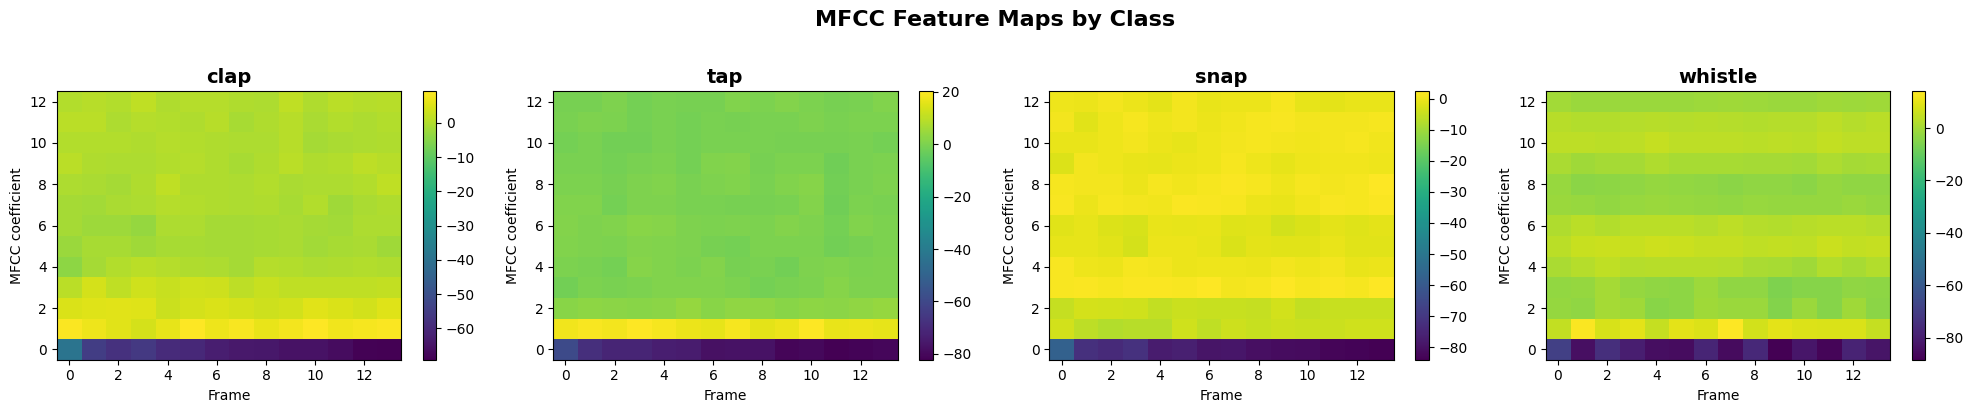

Saved mfcc_visualisation.png


In [ ]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 4))
for i, ax in enumerate(axes):
    idx = np.where(y == i)[0]
    if len(idx) == 0:
        ax.set_title(f"{CLASSES[i]}\n(no data)")
        continue
    mfcc_sample = X_mfcc[idx[0]]   # (n_frames, n_mfcc)
    im = ax.imshow(mfcc_sample.T, aspect="auto", origin="lower",
                   cmap=cm.viridis, interpolation="nearest")
    ax.set_title(f"{CLASSES[i]}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Frame")
    ax.set_ylabel("MFCC coefficient")
    plt.colorbar(im, ax=ax)

plt.suptitle("MFCC Feature Maps by Class", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("mfcc_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mfcc_visualisation.png")


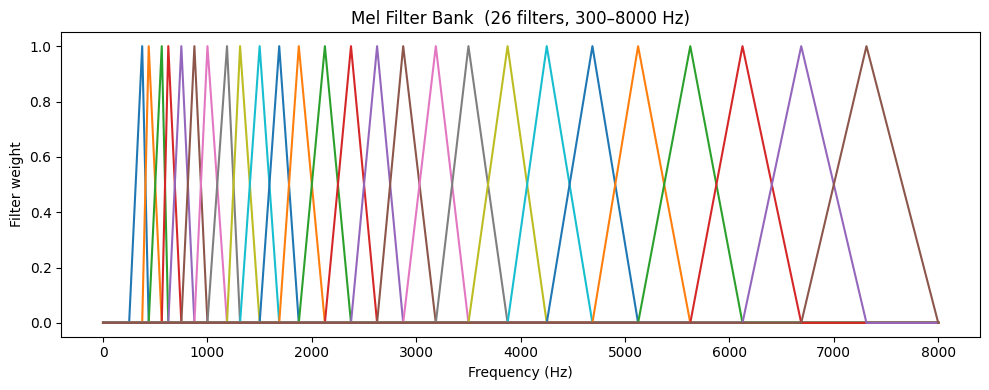

In [ ]:
# Visualisaton of the Mel filter bank
fig, ax = plt.subplots(figsize=(10, 4))
freqs = np.linspace(0, SAMPLE_RATE / 2, FFT_SIZE // 2 + 1)
for m in range(N_MELS):
    ax.plot(freqs, MEL_FILTERBANK[m])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Filter weight")
ax.set_title(f"Mel Filter Bank  ({N_MELS} filters, {F_MIN:.0f}–{F_MAX:.0f} Hz)")
plt.tight_layout()
plt.savefig("mel_filterbank.png", dpi=150)
plt.show()


## 7. Normalise & Split Dataset

We compute **per-coefficient mean and standard deviation** on the training split only,
then save these values. The Arduino sketch will apply the same z-score normalisation
before running inference.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_mfcc, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

# Compute stats over (samples, frames) axes → shape (1, 1, n_mfcc)
mean = X_train.mean(axis=(0, 1), keepdims=True)   # broadcast-ready
std  = X_train.std (axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"mean shape: {mean.shape}, std shape: {std.shape}")

np.save("norm_mean.npy", mean)
np.save("norm_std.npy",  std)
print("Normalisation parameters saved.")


Train : (48, 14, 13)
Val   : (16, 14, 13)
Test  : (16, 14, 13)
mean shape: (1, 1, 13), std shape: (1, 1, 13)
Normalisation parameters saved.


## 8. Build Lightweight 1-D CNN

Architecture:  
`Input → Conv1D(16) → MaxPool1D → Conv1D(32) → MaxPool1D → Flatten → Dense(Softmax)`


In [ ]:
# Input shape: (n_frames, n_mfcc)  — Conv1D treats n_mfcc as feature channels
input_shape = (X_train.shape[1], N_MFCC)   # (n_frames, 13)

def build_model(input_shape, num_classes):
    inp = keras.Input(shape=input_shape, name="mfcc_input")

    # ── Conv block 1 ──────────────────────────────────────────────────────
    x = layers.Conv1D(16, kernel_size=5, padding="same",
                      activation="relu", name="conv1")(inp)
    x = layers.MaxPooling1D(pool_size=2, name="pool1")(x)

    # ── Conv block 2 ──────────────────────────────────────────────────────
    x = layers.Conv1D(32, kernel_size=3, padding="same",
                      activation="relu", name="conv2")(x)
    x = layers.MaxPooling1D(pool_size=2, name="pool2")(x)

    # ── Classification head ───────────────────────────────────────────────
    x = layers.Flatten(name="flatten")(x)
    out = layers.Dense(num_classes, activation="softmax", name="output")(x)

    return keras.Model(inp, out, name="KWS_1DCNN")


model = build_model(input_shape, NUM_CLASSES)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


Model: "KWS_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 14, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 14, 16)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 7, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 7, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,012 (11.77 KB)

 Trainable params: 3,012 (11.77 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train

Epoch 1/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3958 - loss: 1.3279 - val_accuracy: 0.8125 - val_loss: 1.0436 - learning_rate: 0.0010
Epoch 2/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7917 - loss: 0.9028 - val_accuracy: 0.8750 - val_loss: 0.7881 - learning_rate: 0.0010
Epoch 3/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9375 - loss: 0.6788 - val_accuracy: 0.9375 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 4/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9583 - loss: 0.5082 - val_accuracy: 1.0000 - val_loss: 0.4389 - learning_rate: 0.0010
Epoch 5/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9583 - loss: 0.3706 - val_accuracy: 1.0000 - val_loss: 0.3103 - learning_rate: 0.0010
Epoch 6/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9792 - loss: 0.2553 - val_accuracy: 1.0000 - val_loss: 0.2136 - learning_rate: 0.0010
Epoch 7/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9792 - loss: 0.1763 - val_accuracy: 

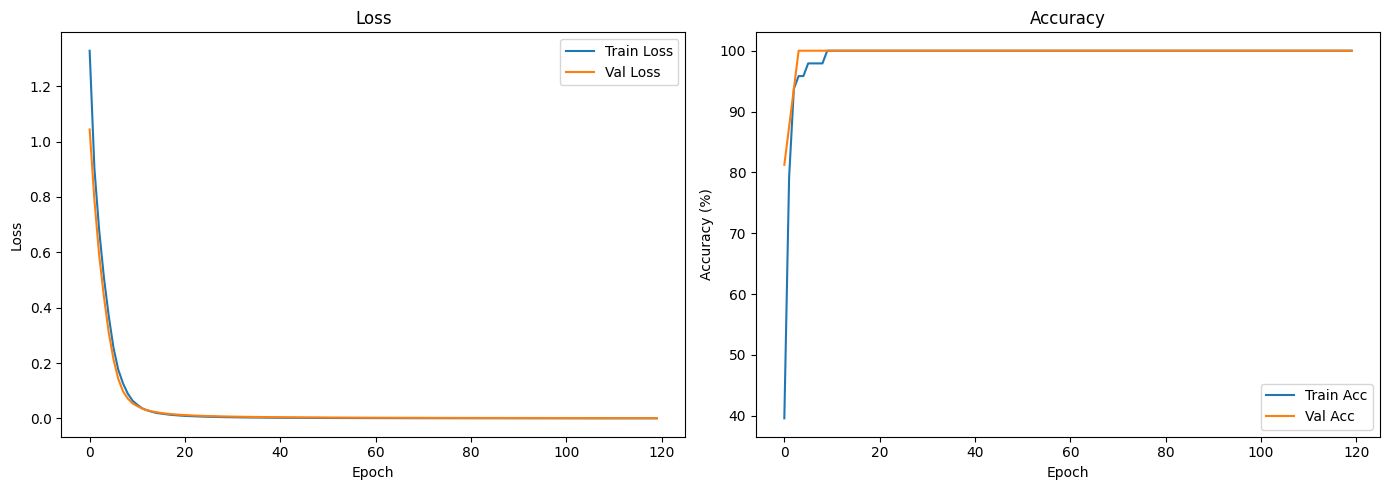

Saved training_curves.png


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=7, verbose=1, min_lr=1e-6),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=8,     # small batch — few training samples
    callbacks=callbacks,
    verbose=1,
)

# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history["loss"],     label="Train Loss")
ax1.plot(history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.set_title("Loss")

ax2.plot(np.array(history.history["accuracy"])     * 100, label="Train Acc")
ax2.plot(np.array(history.history["val_accuracy"]) * 100, label="Val Acc")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.set_title("Accuracy")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved training_curves.png")


## 10. Evaluate — Accuracy & Confusion Matrix

Test accuracy : 100.00%
Test loss     : 0.0005

Classification Report:
              precision    recall  f1-score   support

        clap       1.00      1.00      1.00         4
         tap       1.00      1.00      1.00         4
        snap       1.00      1.00      1.00         4
     whistle       1.00      1.00      1.00         4

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



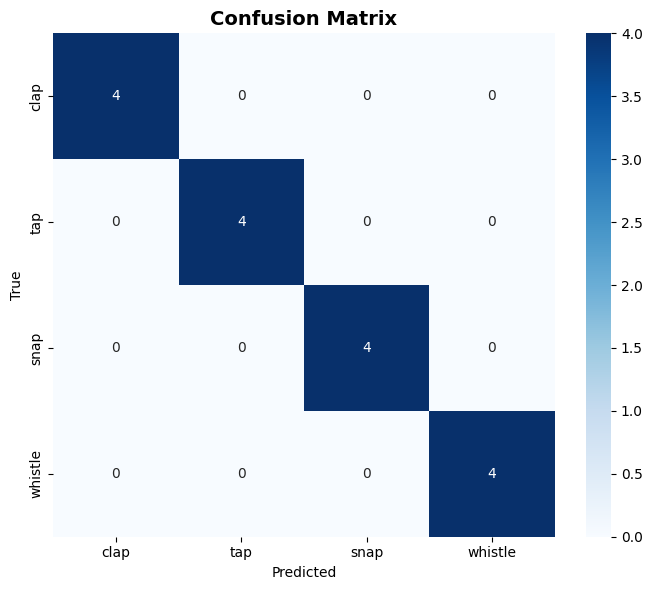

Saved confusion_matrix.png


In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy : {acc*100:.2f}%")
print(f"Test loss     : {loss:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion_matrix.png")


## 11. Export TFLite Model (INT8 Quantised)

We use **full-integer quantisation** (INT8 weights + activations).  
This keeps the model tiny enough to fit in the Arduino's 256 KB SRAM.


In [ ]:
# Representative dataset for calibration
def representative_dataset():
    for i in range(min(len(X_train), 100)):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations           = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset  = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type    = tf.float32   # keep float I/O for simplicity
converter.inference_output_type   = tf.float32

tflite_model = converter.convert()

with open("kws_model.tflite", "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"TFLite model size: {size_kb:.1f} KB")
if size_kb > 200:
    print("⚠  Model >200 KB — consider reducing filters or N_MFCC.")
else:
    print("✓  Model fits well within 256 KB SRAM.")

model.save("kws_model.keras")
print("Keras model saved.")


Saved artifact at '/tmp/tmp_wowkmn7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 14, 13), dtype=tf.float32, name='mfcc_input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  134331040780304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134331040781072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134331040782992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134331040782800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134331040784912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134331040783184: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model size: 11.0 KB
✓  Model fits well within 256 KB SRAM.
Keras model saved.


In [ ]:
# Export a C byte array for direct embedding into the Arduino sketch
with open("kws_model.tflite", "rb") as f:
    tflite_bytes = f.read()

c_array  = ", ".join(f"0x{b:02x}" for b in tflite_bytes)
c_header = f"""// Auto-generated by KWS_MFCC_Training.ipynb
// TFLite model — INT8 quantised
#pragma once
#include <stdint.h>

const unsigned int kws_model_len = {len(tflite_bytes)};
alignas(8) const uint8_t kws_model_data[] = {{
  {c_array}
}};
"""

os.makedirs("arduino_weights", exist_ok=True)
with open("arduino_weights/kws_model_data.h", "w") as f:
    f.write(c_header)
print(f"C header written: arduino_weights/kws_model_data.h  ({len(tflite_bytes)} bytes)")


C header written: arduino_weights/kws_model_data.h  (11240 bytes)


## 12. Export Normalisation Parameters & Mel Filter Bank as C Headers

The Arduino sketch needs the same **mean**, **std** and **Mel filter bank** that were
used during training.


In [ ]:
def float_array_to_c(arr, name):
    """Convert a numpy float32 array to a C `static const float` literal."""
    flat  = arr.flatten().astype(np.float32)
    vals  = ",\n  ".join(f"{v:.8f}f" for v in flat)
    shape = " x ".join(str(d) for d in arr.shape)
    return (f"// shape: {shape}\n"
            f"static const float {name}[{len(flat)}] PROGMEM = {{\n  {vals}\n}};\n")


header = [
    "// Auto-generated by KWS_MFCC_Training.ipynb",
    "// DO NOT EDIT MANUALLY",
    "#pragma once",
    "#include <stdint.h>",
    "#include <avr/pgmspace.h>",
    "",
    f"#define KWS_NUM_CLASSES  {NUM_CLASSES}",
    f"#define KWS_N_MFCC       {N_MFCC}",
    f"#define KWS_N_MELS       {N_MELS}",
    f"#define KWS_N_FRAMES     {N_FRAMES}",
    f"#define KWS_FRAME_LEN    {FRAME_LEN}",
    f"#define KWS_HOP_LEN      {HOP_LEN}",
    f"#define KWS_FFT_SIZE     {FFT_SIZE}",
    f"#define KWS_SAMPLE_RATE  {SAMPLE_RATE}",
    "",
    f"static const char* KWS_CLASS_NAMES[{NUM_CLASSES}] = {{",
]
header += [f'  "{c}",' for c in CLASSES]
header += ["};", ""]

# Normalisation only — mean/std are the only training-dependent values.
# KWS_MEL_FBANK, KWS_HAMMING_WIN and KWS_DCT live in mfcc_tables.h
# (pre-computed from fixed parameters, never change after training).
header.append(float_array_to_c(mean.flatten(), "KWS_NORM_MEAN"))
header.append(float_array_to_c(std.flatten(),  "KWS_NORM_STD"))

os.makedirs("arduino_weights", exist_ok=True)
path = "arduino_weights/kws_params.h"
with open(path, "w") as f:
    f.write("\n".join(header))

print(f"Parameters exported to {path}  ({os.path.getsize(path)//1024} KB)")
print("NOTE: KWS_MEL_FBANK / KWS_HAMMING_WIN / KWS_DCT are in mfcc_tables.h — not duplicated here.")


Parameters exported to arduino_weights/kws_params.h  (0 KB)
NOTE: KWS_MEL_FBANK / KWS_HAMMING_WIN / KWS_DCT are in mfcc_tables.h — not duplicated here.


## 13. Validate TFLite Model

In [ ]:
interpreter = tf.lite.Interpreter(model_path="kws_model.tflite")
interpreter.allocate_tensors()

in_idx  = interpreter.get_input_details()[0]["index"]
out_idx = interpreter.get_output_details()[0]["index"]

tflite_preds = []
for i in range(len(X_test)):
    interpreter.set_tensor(in_idx, X_test[i:i+1].astype(np.float32))
    interpreter.invoke()
    tflite_preds.append(interpreter.get_tensor(out_idx)[0])

tflite_preds = np.array(tflite_preds)
tflite_classes = np.argmax(tflite_preds, axis=1)

tflite_acc = np.mean(tflite_classes == y_test)
print(f"TFLite model accuracy : {tflite_acc*100:.2f}%")
print(f"Keras  model accuracy : {acc*100:.2f}%")
print(f"Accuracy drop due to quantisation: {(acc - tflite_acc)*100:.2f}%")


TFLite model accuracy : 100.00%
Keras  model accuracy : 100.00%
Accuracy drop due to quantisation: 0.00%


## 14. Download All Outputs

In [ ]:
try:
    from google.colab import files

    outputs = [
        "arduino_weights/kws_model_data.h",
        "arduino_weights/kws_params.h",
        "kws_model.tflite",
        "kws_model.keras",
        "mfcc_visualisation.png",
        "mel_filterbank.png",
        "training_curves.png",
        "confusion_matrix.png",
        "norm_mean.npy",
        "norm_std.npy",
    ]
    for p in outputs:
        if os.path.exists(p):
            files.download(p)
            print(f"Downloading {p}")
        else:
            print(f"Not found   {p}")
except ImportError:
    print("Not running in Colab — outputs are in the current directory.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>